# **Crime Count Prediction Using Machine Learning**


Crime is influenced by several factors such as location, time of day, day of the week, and season. Understanding these patterns can help in resource planning and public safety.

In this project, we analyze crime data from Los Angeles and build machine learning models to predict the expected number of crimes occurring in a specific area and time period. The project follows a complete machine learning workflow including data cleaning, exploratory data analysis, feature engineering, model building, and evaluation.

Loading the Dataset

The first step is to load the dataset into a Pandas DataFrame. Before performing any analysis, it is important to inspect the data and understand its structure.

We begin by examining the date column because time-based information will play an important role in our analysis and prediction model.

In [40]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Crime_Data_from_2020_to_2024.csv')

print("Original Shape:", df.shape)

Original Shape: (1004894, 28)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

In [42]:
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004894e+06,1.004878e+06,327216.000000,1.004883e+06,69154.000000,2314.000000,64.00000,1.004894e+06,1.004894e+06
mean,2.202190e+08,1.339901e+03,1.069153e+01,1.115613e+03,1.400313e+00,5.001386e+02,2.891862e+01,3.056108e+02,363.950797,4.998992e+02,958.097796,984.015990,991.21875,3.399820e+01,-1.180908e+02
std,1.319070e+07,6.510761e+02,6.110248e+00,6.111596e+02,4.899620e-01,2.052638e+02,2.199267e+01,2.192913e+02,123.737665,2.050643e+02,110.358509,52.350982,27.06985,1.610789e+00,5.582654e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106168e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209158e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311102e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521040e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [43]:
# Missing values
df.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Rpt Dist No,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0


In [44]:
df.duplicated().sum()

np.int64(0)

The original dataset contains records from 2020 onwards.

To focus on recent crime patterns, only records from 2023 and 2024 are retained. This helps the model learn from more current data and reduces the influence of older trends that may no longer be relevant.

In [45]:
print(df['DATE OCC'].head())

0    11/07/2020 12:00:00 AM
1    10/18/2020 12:00:00 AM
2    10/30/2020 12:00:00 AM
3    12/24/2020 12:00:00 AM
4    09/29/2020 12:00:00 AM
Name: DATE OCC, dtype: object


In [46]:
# convert date

df['DATE OCC'] = pd.to_datetime(
    df['DATE OCC'],
    errors='coerce'
)

/tmp/ipykernel_4071/2619862899.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(


In [47]:
print(df['DATE OCC'].dtype)
print("Missing Dates:", df['DATE OCC'].isnull().sum())

datetime64[ns]
Missing Dates: 0


In [48]:
print(df['DATE OCC'].dt.year.value_counts().sort_index())

DATE OCC
2020    199847
2021    209876
2022    235259
2023    232345
2024    127567
Name: count, dtype: int64


In [49]:
# keep 2023 and 2024

df = df[df['DATE OCC'].dt.year >= 2023]

print("After Filter:", df.shape)

After Filter: (359912, 28)


## Removing Unnecessary Columns

Not every column in a dataset is useful for analysis or prediction. Before building the model, the dataset was examined to identify columns that contained excessive missing values, duplicated information, or were not directly related to predicting crime counts.

Columns such as Crm Cd 2, Crm Cd 3, Crm Cd 4, Cross Street, Mocodes, Premis Cd, Premis Desc, Status, and Crm Cd 1 were removed because they either had a large number of missing values or provided information that was not essential for the objective of this project.

Removing these columns helps reduce noise, simplifies the dataset, and allows the machine learning model to focus on more meaningful features.

In [50]:
df.drop(
    columns=[
        'Crm Cd 2',
        'Crm Cd 3',
        'Crm Cd 4',
        'Cross Street',
        'Mocodes',
        'Premis Cd',
        'Premis Desc',
        'Status',
        'Crm Cd 1'
    ],
    inplace=True
)

## Handling Missing Values in Victim and Weapon Information

Some records in the dataset contain missing information related to victim details and weapon usage. Instead of removing these records, appropriate placeholder values are assigned to preserve the data.

For victim-related fields, missing values are replaced with "Unknown" to indicate that the information was not reported. Similarly, missing weapon descriptions are replaced with "No Weapon Reported", while missing weapon codes are assigned a value of 0.

This approach allows all records to be retained in the dataset while clearly distinguishing missing information from valid entries.

In [51]:
df.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Rpt Dist No,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0


In [52]:
df['Vict Sex'] = df['Vict Sex'].fillna('Unknown')

df['Vict Descent'] = df['Vict Descent'].fillna('Unknown')

df['Weapon Desc'] = df['Weapon Desc'].fillna('No Weapon Reported')

df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0)

In [53]:
print(df.isnull().sum().sum())

0


## Creating Time-Based Features

The original dataset contains the date and time of each crime occurrence. While this information is useful, machine learning models can better understand patterns when individual components such as hour, day, and month are available separately.

Therefore, new features are extracted from the date and time columns. These features help identify when crimes are more likely to occur and allow both the EDA and machine learning models to capture temporal patterns more effectively.

Hour helps analyze crime occurrence throughout the day.
Day helps identify differences between weekdays.
Month helps detect seasonal and monthly crime trends.

By creating these features, the dataset becomes more informative and better suited for pattern analysis and prediction.

In [54]:
# create hour

df['Hour'] = df['TIME OCC'] // 100

# create day

df['Day'] = df['DATE OCC'].dt.day_name()

# create month

df['Month'] = df['DATE OCC'].dt.month

In [55]:
hour_counts = df['Hour'].value_counts().sort_index()

In [56]:
df['Crm Cd Desc'].value_counts().head(10)

,count
Crm Cd Desc,
VEHICLE - STOLEN,45981
BATTERY - SIMPLE ASSAULT,24232
BURGLARY FROM VEHICLE,23090
"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",21117
THEFT PLAIN - PETTY ($950 & UNDER),20280
THEFT OF IDENTITY,19937
SHOPLIFTING - PETTY THEFT ($950 & UNDER),19071
BURGLARY,18749
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",16389


## Exploratory Data Analysis (EDA)

Before building a machine learning model, it is important to understand the data.

EDA helps answer questions such as:

When do crimes occur most frequently?
Which areas experience more crime?
Does crime vary throughout the year?
Do weekdays and weekends behave differently?

The insights obtained during this stage also help justify the features used in the prediction model.

## Crime Occurrence by Hour

This visualization shows how crime counts vary throughout the day.

The purpose of this analysis is to identify high-crime hours and determine whether time of day has an influence on crime occurrence.

The findings from this graph later help explain why Hour becomes one of the most important features in the machine learning model.

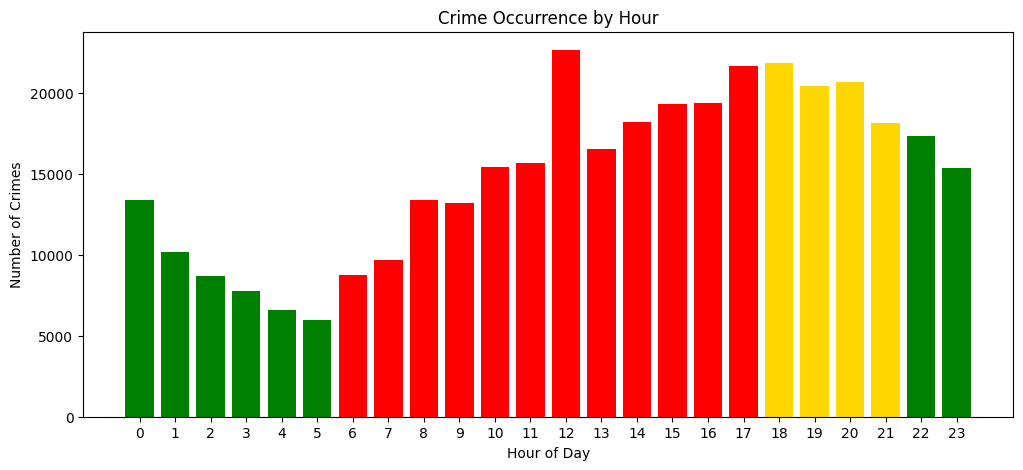

In [57]:
hour_counts = df['Hour'].value_counts().sort_index()

colors = []

for h in hour_counts.index:
    if 6 <= h < 18:
        colors.append('red')
    elif 18 <= h < 22:
        colors.append('gold')
    else:
        colors.append('green')

plt.figure(figsize=(12,5))

plt.bar(
    hour_counts.index,
    hour_counts.values,
    color=colors
)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Crimes')
plt.title('Crime Occurrence by Hour')

plt.xticks(range(24))

plt.show()

## Crime Intensity Heatmap

The heatmap combines day of the week and hour of the day into a single visualization.

This allows us to identify periods where crime activity is particularly concentrated and helps reveal patterns that may not be visible in individual charts.

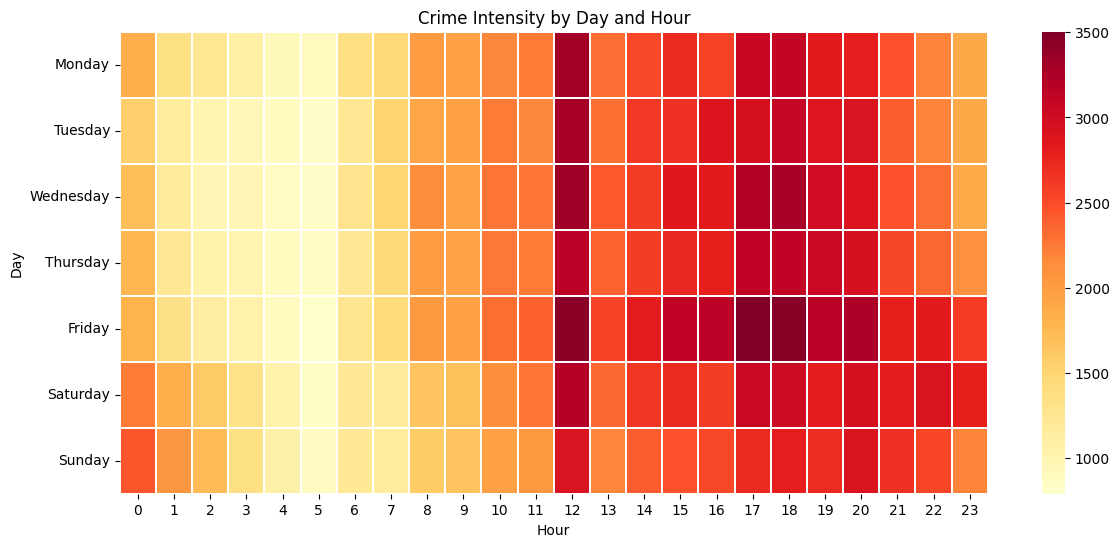

In [58]:
heat = pd.crosstab(
    df['Day'],
    df['Hour']
)

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

heat = heat.reindex(day_order)

plt.figure(figsize=(14,6))

sns.heatmap(
    heat,
    cmap='YlOrRd',
    linewidths=0.2
)

plt.title('Crime Intensity by Day and Hour')
plt.xlabel('Hour')
plt.ylabel('Day')

plt.show()

## Monthly Crime Trend

Crime levels may change throughout the year due to seasonal and social factors.

This analysis helps determine whether certain months consistently experience higher or lower crime volumes.

The results support the inclusion of Month and Season as predictive features.

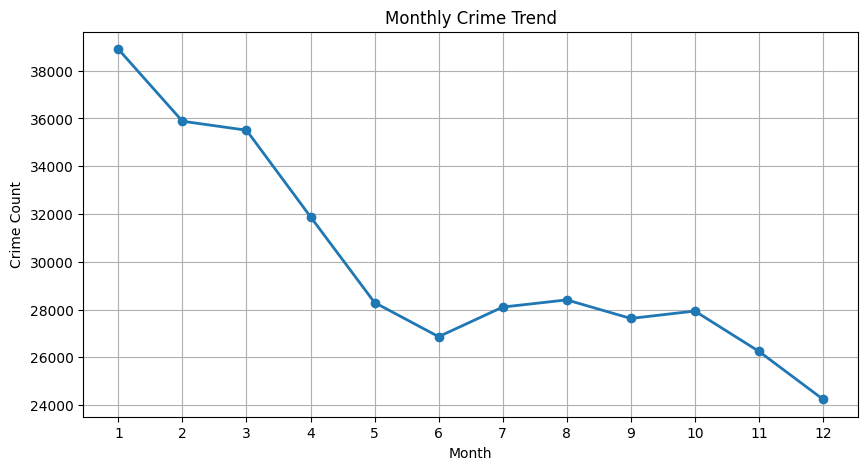

In [59]:
monthly = df.groupby('Month').size()

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker='o',
    linewidth=2
)

plt.xlabel('Month')
plt.ylabel('Crime Count')
plt.title('Monthly Crime Trend')

plt.xticks(range(1,13))

plt.grid(True)

plt.show()

## Crime Distribution Across Areas

Crime is not evenly distributed across all locations.

This analysis identifies areas with higher crime concentrations and helps explain why location-based information is important for prediction.

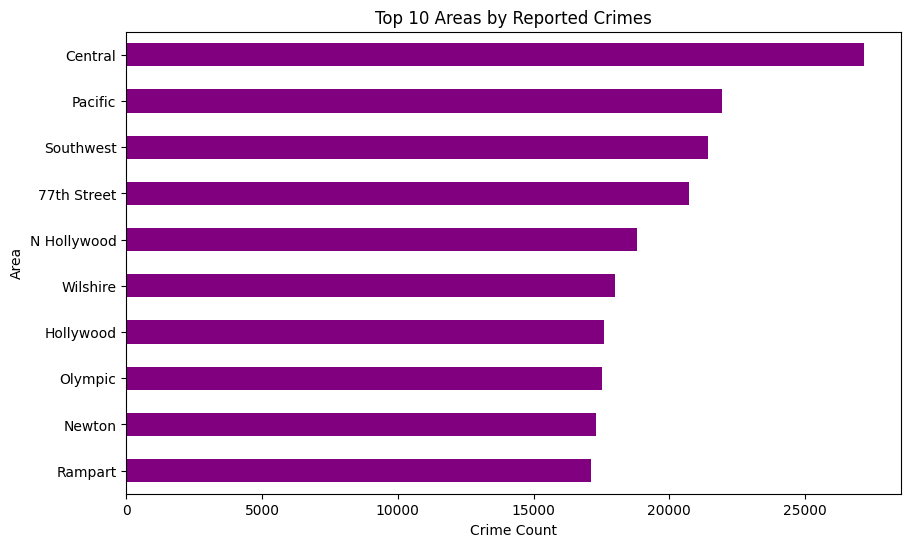

In [60]:
area_counts = (
    df['AREA NAME']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

area_counts.sort_values().plot(
    kind='barh',
    color='purple'
)

plt.xlabel('Crime Count')
plt.ylabel('Area')
plt.title('Top 10 Areas by Reported Crimes')

plt.show()

## Creating the Regression Dataset

The original dataset contains one row per crime incident.

However, **the objective of this project is to predict the number of crimes** occurring within a particular area and time period.

To achieve this, the data is aggregated by:

Area
Month
Day
Hour

The number of crimes in each combination is counted and stored as Crime_Count.

This Crime_Count variable becomes the target variable for regression.

In [61]:
crime_counts = (
    df.groupby(
        ['AREA NAME','Month','Day','Hour']
    )
    .size()
    .reset_index(name='Crime_Count')
)

print(crime_counts.shape)

(41941, 5)


In [62]:
crime_model = crime_counts.copy()

## Preparing Data for Machine Learning

Machine learning algorithms require numerical inputs.

Categorical variables such as Area Name, Day, Season, and Time Period are converted into numerical form using Label Encoding.

This allows the models to process the information while preserving category distinctions.

In [63]:
crime_model['Weekend'] = crime_model['Day'].isin(
    ['Saturday','Sunday']
).astype(int)

In [64]:
def time_period(hour):

    if 5 <= hour < 12:
        return 'Morning'

    elif 12 <= hour < 17:
        return 'Afternoon'

    elif 17 <= hour < 21:
        return 'Evening'

    else:
        return 'Night'

crime_model['Time_Period'] = crime_model['Hour'].apply(time_period)

In [65]:
def season(month):

    if month in [12,1,2]:
        return 'Winter'

    elif month in [3,4,5]:
        return 'Spring'

    elif month in [6,7,8]:
        return 'Summer'

    else:
        return 'Fall'

crime_model['Season'] = crime_model['Month'].apply(season)

In [66]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
le_day = LabelEncoder()
le_time = LabelEncoder()
le_season = LabelEncoder()

crime_model['AREA NAME'] = le_area.fit_transform(crime_model['AREA NAME'])
crime_model['Day'] = le_day.fit_transform(crime_model['Day'])
crime_model['Time_Period'] = le_time.fit_transform(crime_model['Time_Period'])
crime_model['Season'] = le_season.fit_transform(crime_model['Season'])

In [67]:
X = crime_model[
    [
        'AREA NAME',
        'Month',
        'Day',
        'Hour',
        'Weekend',
        'Time_Period',
        'Season'
    ]
]

y = crime_model['Crime_Count']

## Train-Test Split

To evaluate model performance fairly, the dataset is divided into training and testing sets.

The training data is used to learn patterns, while the testing data is used to measure how well the model performs on unseen examples.

This helps determine whether the model can generalize beyond the data it was trained on.

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression Model

Linear Regression is used as a baseline model.

It assumes a linear relationship between the input features and the target variable.

Using a simple model first provides a useful reference point and helps evaluate whether more advanced algorithms offer improvements.

In [69]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [70]:
pred_lr = lr.predict(X_test)

In [71]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R²  :", r2_score(y_test, pred_lr))

MAE : 3.3185828746796933
RMSE: 4.365929521368137
R²  : 0.26625016509810584


## Overfitting Analysis

A model should perform well not only on training data but also on unseen data.

To verify this, training and testing performance are compared.

If the training score is much higher than the testing score, the model may be overfitting.

A small gap between the two scores indicates better generalization.

In [72]:
train_pred_lr = lr.predict(X_train)

print("Training R²:", r2_score(y_train, train_pred_lr))
print("Testing R² :", r2_score(y_test, pred_lr))

Training R²: 0.29150400988362746
Testing R² : 0.26625016509810584


## Actual vs Predicted Values

After training the Linear Regression model, it is important to compare the predicted crime counts with the actual crime counts.

This visualization helps us understand how closely the model's predictions match the real values. If the points lie close to the reference line, the predictions are more accurate. Larger deviations from the line indicate prediction errors.

This graph provides a visual assessment of the model's performance in addition to numerical evaluation metrics such as MAE, RMSE, and R².

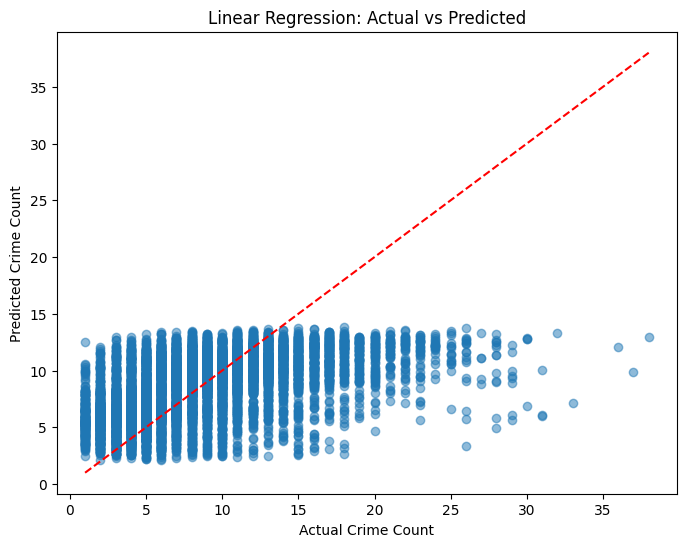

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_lr,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Crime Count')
plt.ylabel('Predicted Crime Count')
plt.title('Linear Regression: Actual vs Predicted')

plt.show()

In [74]:
print("Intercept:", lr.intercept_)

for feature, coef in zip(X.columns, lr.coef_):
    print(f"{feature}: {coef}")

Intercept: 10.155323452041237
AREA NAME: -0.02428768471769671
Month: -0.3192251095716791
Day: -0.1037118396449787
Hour: 0.253795386054896
Weekend: -0.07562561880081313
Time_Period: -1.071068703035682
Season: -0.010340167018570828


## Random Forest and XGBoost Models

Crime patterns are often complex and non-linear.

Tree-based models such as Random Forest and XGBoost are capable of capturing these complex relationships more effectively than Linear Regression.

These models are trained and compared to identify the approach that provides the most accurate predictions.

## Random Forest Model

Linear Regression assumes a linear relationship between the input features and crime count. However, crime patterns are often more complex and may involve non-linear interactions between location, time, and seasonal factors.

To capture these complex relationships, a Random Forest Regressor is used. Random Forest builds multiple decision trees and combines their predictions to produce a final result.

Using multiple trees helps improve prediction accuracy and reduces the risk of relying on a single decision tree. This makes Random Forest a powerful model for handling real-world datasets with complex patterns.

In [75]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [76]:
pred_rf = rf.predict(X_test)

In [77]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R²  :", r2_score(y_test, pred_rf))

MAE : 2.6488624491245756
RMSE: 3.482470856934986
R²  : 0.5331583916283883


## Checking for Overfitting

A model should perform well on both training data and unseen testing data.

To verify this, the R² score is calculated on both datasets. A small difference between the two scores indicates that the model has learned general patterns rather than memorizing the training data.

In [78]:
train_pred_rf = rf.predict(X_train)

print("Training R²:", r2_score(y_train, train_pred_rf))
print("Testing R² :", r2_score(y_test, pred_rf))

Training R²: 0.5781628750755341
Testing R² : 0.5331583916283883


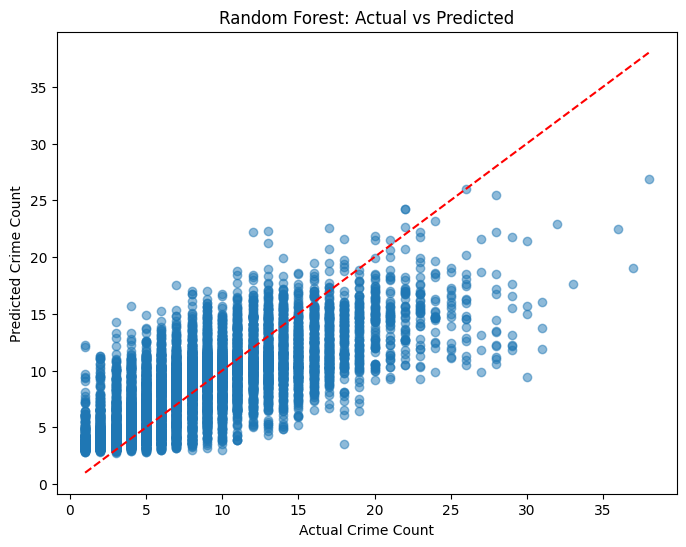

In [79]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Crime Count')
plt.ylabel('Predicted Crime Count')
plt.title('Random Forest: Actual vs Predicted')

plt.show()

## Observation

The Random Forest model achieved a Training R² of 0.578 and a Testing R² of 0.533.

The small difference between the two scores indicates that the model generalizes reasonably well and does not show significant overfitting. The model is able to capture meaningful patterns in the data while maintaining consistent performance on unseen records.

## XGBoost Model Training

After evaluating simpler models, XGBoost is used to improve prediction performance.

XGBoost is an ensemble learning algorithm that builds multiple decision trees sequentially. Each new tree attempts to correct the mistakes made by the previous trees, allowing the model to learn complex patterns in the data.

Several parameters are adjusted to balance prediction accuracy and model generalization. The objective is to achieve strong performance while reducing the risk of overfitting.

The model is then trained using the training dataset so that it can learn the relationship between the input features and the crime count.


In [80]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [81]:
pred_xgb = xgb.predict(X_test)

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))
print("R² :", r2_score(y_test, pred_xgb))

MAE : 2.4993720054626465
RMSE: 3.2863710677001614
R² : 0.584254264831543


## Checking for Overfitting

A machine learning model should perform well not only on the training data but also on unseen data.

To verify this, the R² score is calculated for both the training set and the testing set. If the training score is much higher than the testing score, the model may have memorized the training data instead of learning general patterns.

Comparing these two scores helps determine whether the model is able to generalize effectively to new data.


In [83]:
train_pred = xgb.predict(X_train)

print("Training R²:", r2_score(y_train, train_pred))
print("Testing R² :", r2_score(y_test, pred_xgb))

Training R²: 0.6211488246917725
Testing R² : 0.584254264831543


### Observation

The XGBoost model achieved a training R² score of **0.621** and a testing R² score of **0.584**.

The difference between the two scores is relatively small, indicating that the model performs consistently on both training and unseen data. This suggests that overfitting has been successfully controlled and the model is able to generalize reasonably well.

Overall, the model captures meaningful crime patterns while maintaining stable performance on new data.


## Cross Validation

A single train-test split may sometimes give an overly optimistic or pessimistic estimate of model performance.

To obtain a more reliable evaluation, 5-Fold Cross Validation is performed. The dataset is divided into five parts, and the model is trained and tested five times using different subsets of the data.

This helps us check whether the model performs consistently across different data splits.

In [84]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Fold R² Scores:")
print(scores)

print("\nMean R²:", np.mean(scores))
print("Std Dev :", np.std(scores))

Fold R² Scores:
[0.20610094 0.41835165 0.28934443 0.38860303 0.5232169 ]

Mean R²: 0.3651233911514282
Std Dev : 0.10900338558184355


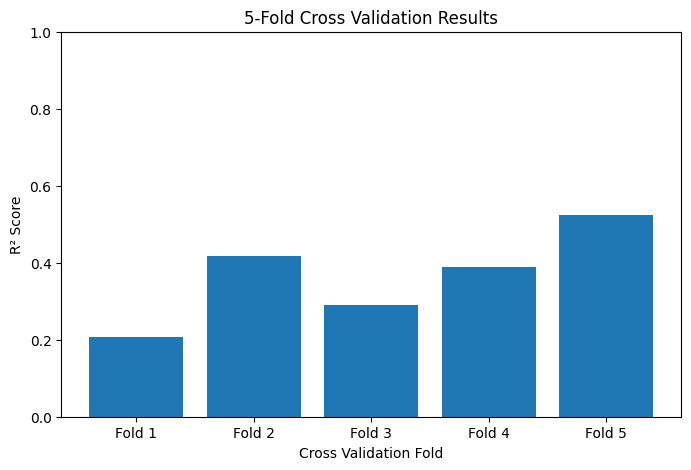

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    [f'Fold {i+1}' for i in range(5)],
    scores
)

plt.ylabel('R² Score')
plt.xlabel('Cross Validation Fold')
plt.title('5-Fold Cross Validation Results')

plt.ylim(0, 1)

plt.show()

### Observation

The model achieved positive R² scores across all five folds, indicating that it is able to capture meaningful patterns in the data.

However, the variation between folds suggests that model performance depends on the specific subset of data used for training and testing. This is expected because crime patterns can vary across different locations and time periods.

Cross validation provides a more realistic estimate of model performance and helps verify that the model is not relying on a single train-test split.


## Feature Importance Analysis

After training the XGBoost model, it is useful to understand which features contributed the most to the predictions.

This analysis helps explain how the model makes decisions and identifies the factors that have the greatest influence on crime count prediction.


In [86]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

       Feature  Importance
3         Hour    0.313364
5  Time_Period    0.255513
0    AREA NAME    0.152188
1        Month    0.112524
4      Weekend    0.077051
6       Season    0.045541
2          Day    0.043819


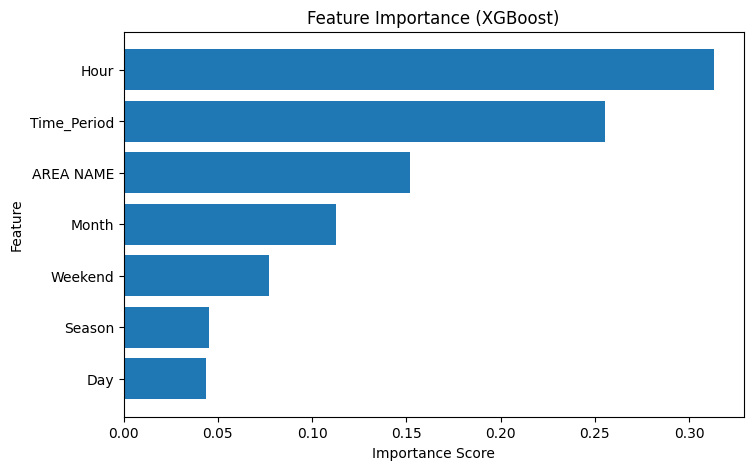

In [87]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance (XGBoost)')

plt.gca().invert_yaxis()

plt.show()

### Observation

The graph shows that **Hour** and **Time Period** are the most important features. This indicates that crime occurrence is strongly influenced by the time of day. Location and month also contribute to the prediction, while day of the week has a relatively smaller impact.


In [88]:
weekend_crime = df.groupby(
    df['Day'].isin(['Saturday','Sunday'])
).size()

print(weekend_crime)

Day
False    256847
True     103065
dtype: int64


## Comparing Weekday and Weekend Crime Activity

Crime patterns may differ between weekdays and weekends due to changes in people's daily routines, work schedules, social activities, and public movement.

To investigate this, the crime records are divided into two groups: weekdays and weekends. The total number of crimes in each group is then compared using a bar chart.

The purpose of this analysis is to determine whether weekends experience significantly different crime levels and whether the Weekend feature may be useful for predicting crime counts.

This analysis helps answer the question:

Does crime occurrence change noticeably between weekdays and weekends?

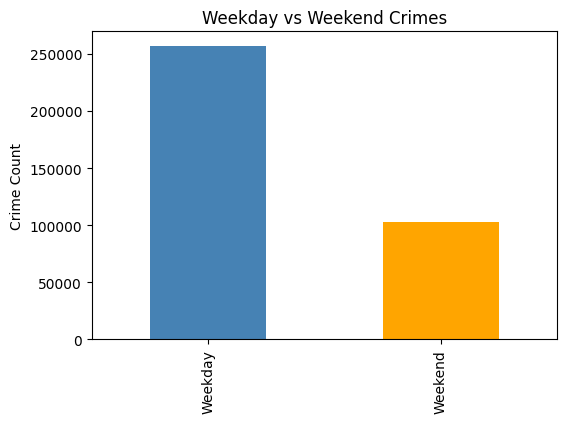

In [89]:
weekend_crime.index = ['Weekday','Weekend']

plt.figure(figsize=(6,4))

weekend_crime.plot(
    kind='bar',
    color=['steelblue','orange']
)

plt.ylabel('Crime Count')
plt.title('Weekday vs Weekend Crimes')

plt.show()

In [90]:
day_counts = df['Day'].value_counts()

print(day_counts)

Day
Friday       55070
Saturday     52846
Wednesday    51011
Thursday     50838
Monday       50359
Sunday       50219
Tuesday      49569
Name: count, dtype: int64


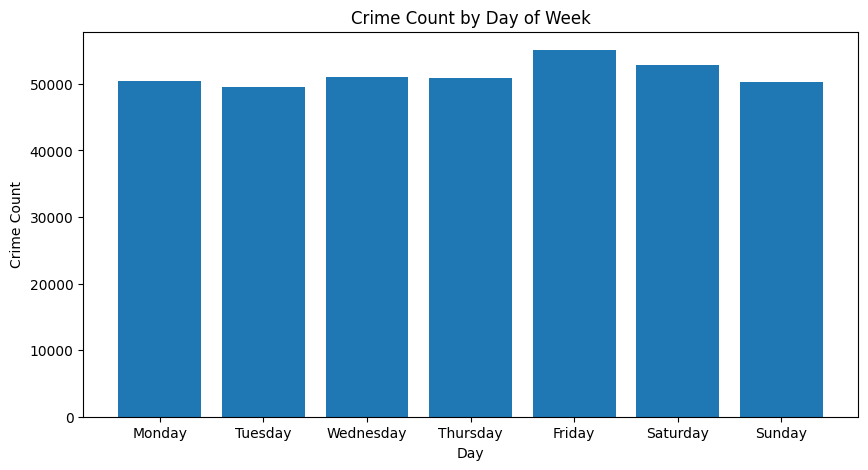

In [91]:
plt.figure(figsize=(10,5))

day_counts = df['Day'].value_counts()

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_counts = day_counts.reindex(day_order)

plt.bar(
    day_counts.index,
    day_counts.values
)

plt.xlabel('Day')
plt.ylabel('Crime Count')
plt.title('Crime Count by Day of Week')

plt.show()

## Observation

Friday recorded the highest number of crimes, followed by Saturday. Tuesday recorded the lowest crime count.

Although some variation exists across the week, the differences are relatively small compared to the overall number of crimes. This suggests that the day of the week has a limited influence on crime occurrence.

 This finding is consistent with the feature importance analysis, where the Day feature contributed only a small amount to the final XGBoost model.

In [92]:
monthly = df.groupby('Month').size()
print(monthly)

Month
1     38896
2     35883
3     35507
4     31883
5     28294
6     26867
7     28105
8     28406
9     27630
10    27939
11    26253
12    24249
dtype: int64


## Model Evaluation

Model performance is evaluated using three metrics:

MAE (Mean Absolute Error)
RMSE (Root Mean Squared Error)
R² Score

These metrics provide different perspectives on prediction accuracy and overall model quality.

A higher R² score and lower error values indicate better performance.

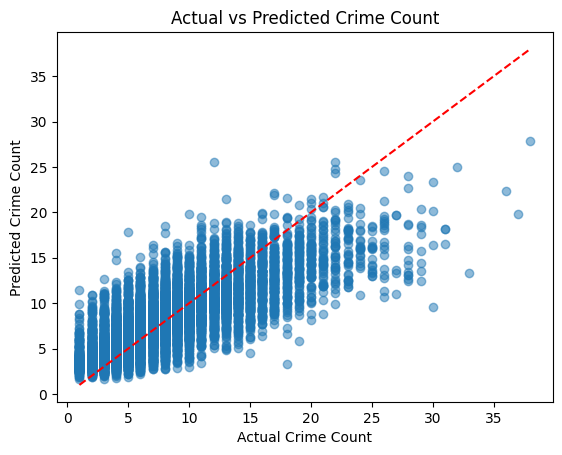

In [93]:
plt.scatter(y_test, pred_xgb, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Crime Count')
plt.ylabel('Predicted Crime Count')
plt.title('Actual vs Predicted Crime Count')

plt.show()

In [94]:
lr_mae = mean_absolute_error(y_test, pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
lr_r2 = r2_score(y_test, pred_lr)

In [95]:
rf_mae = mean_absolute_error(y_test, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
rf_r2 = r2_score(y_test, pred_rf)

In [96]:
xgb_mae = mean_absolute_error(y_test, pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
xgb_r2 = r2_score(y_test, pred_xgb)

In [97]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R²': [lr_r2, rf_r2, xgb_r2],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse]
})

results

,Model,R²,MAE,RMSE
0,Linear Regression,0.266250,3.318583,4.365930
1,Random Forest,0.533158,2.648862,3.482471
2,XGBoost,0.584254,2.499372,3.286371


# Conclusion

In this project, crime data from Los Angeles was analyzed to identify patterns and predict crime counts using machine learning techniques. The dataset was cleaned, transformed, and explored through various visualizations to understand how crime occurrence changes across different locations and time periods.

Feature engineering was performed to create meaningful variables such as Hour, Day, Month, Weekend, Time Period, and Season. These features were then used to build and evaluate multiple regression models, including Linear Regression, Random Forest, and XGBoost.

Among the evaluated models, XGBoost achieved the best performance with an R² score of approximately 0.58, indicating that the model was able to capture a significant portion of the variation in crime counts. Comparison of training and testing scores showed only a small performance gap, suggesting that the model generalized reasonably well and did not suffer from severe overfitting.

Feature importance analysis revealed that time-related variables, particularly Hour and Time Period, were the strongest predictors of crime count. Location-based information also contributed to the predictions, while the day of the week had a relatively smaller impact.

Overall, the project demonstrates that crime patterns can be analyzed and predicted using historical data and machine learning techniques. The findings highlight the importance of temporal and spatial factors in crime occurrence and show how predictive analytics can support data-driven decision making in public safety and resource planning.
